DOSYA YÜKLEME VE ÖZNİTELİK

In [19]:
import pandas as pd

df = pd.read_csv('data/birlesik_veri.csv')

# zaman sütunlarının kullanılabilirliği için dataframe formatına çevirerek dönüşümler yapılır
df['start_time'] = pd.to_datetime(df['start_time']) # tarih
df['saat'] = df['start_time'].dt.hour # saat
df['haftanin_gunu'] = df['start_time'].dt.dayofweek # Haftanın günü al (Pazartesi=0, Pazar=6)
df['ayin_gunu'] = df['start_time'].dt.day # Ayın gününü al (1-31 arası)
df['ay'] = df['start_time'].dt.month # Yılın ayını al (1-12 arası)


# Dedektör ID'lerini diğer dosyalardan gelen bilgilerle birleştirilir
serit_sozlugu = {
    1: 'Sol',
    2: 'Orta',
    3: 'Sağ',
    4: 'Rampa'
}
df['serit_tipi'] = df['detector_id'].map(serit_sozlugu) # sözlük ile şerit isimleri eklenir


arac_tipi_sozlugu = {
1: 'Binek Araba',
3: 'Büyük Araç',
4: 'Otobüs',
5: 'İki Tekerlekli',
6: 'Ağır Taşıt', 
8: 'Diğer'
}
df['arac_tipi'] = df['class_id'].map(arac_tipi_sozlugu)


# .head() yerine .sample(5) ile rastgele 5 satır görelim
print(df.sample(5, random_state=40))


             id  intersection_id          start_time             end_time  \
123515  4191459              354 2022-08-17 17:40:00  2022-08-17 17:45:00   
84750   4081248              354 2022-08-03 10:30:00  2022-08-03 10:35:00   
149347  4260220              354 2022-08-29 22:35:00  2022-08-29 22:40:00   
191879  4364170              354 2022-09-17 21:50:00  2022-09-17 21:55:00   
162645  4294476              354 2022-09-04 11:40:00  2022-09-04 11:45:00   

        detector_id  camera_id  class_id  direction  total  occupancy_time  \
123515            1          1         5          0     20             396   
84750             4          1         1          0      7             396   
149347            2          1         5          0      6             405   
191879            2          1         5          0      2             123   
162645            4          1         5          0      1             520   

        speed  saat  haftanin_gunu  ayin_gunu  ay serit_tipi       a

önceki kefişlerden elde ettiğimiz dedektör yeri ve araç sınıf bilgileri özellik olarak eklendi. Bu sayede değişkenlerin karakterlerini de öğrenerek daha tutarlı tahminler yapabilecek. Örneğin farklı kategori temsil ettiğini, sayıların büyüklük ifadesi şeklinde olmadığı gibi ince öğretimler yapar.

HAFIZA ÖZNİTELİKLERİ EKLEME (lag-kısa , roll-ort)

In [20]:
import numpy as np

# trafiği şerit şerit ele alacağımızdan daha kolay çözümlemek adına şerit ve zamana göre sıralarız
df = df.sort_values(by=['detector_id', 'start_time'])


# Gecikme Öznitelikleri (Lag Features) - Kısa Süreli Hafıza
# Her şeridin kendi geçmişini ele almak için veriyi dedektöre göre gruplayalım
grouped_by_detector = df.groupby('detector_id')


# Her şeridin bir önceki (5 dk), iki önceki (10 dk) ve üç önceki (15 dk) hız ve yoğunluk değerlerini yeni sütun olarak ekleyelim.
# mesela .shift(1) bir önceki satırdaki değeri alır şimdiki satıra getirir karşılaştırmayı kolaylaştıracak
for lag in [1, 2, 3]:
    df[f'hiz_lag_{lag*5}dk'] = grouped_by_detector['speed'].shift(lag)
    df[f'yogunluk_lag_{lag*5}dk'] = grouped_by_detector['total'].shift(lag)


# Hareketli Ortalamalar (Rolling Averages) - Orta Süreli Hafıza
# Her şeridin son 30 dakika (6 kayıt) ve 1 saatteki (12 kayıt) ortalama hız ve yoğunluğunu hesaplanır
# .rolling(window=...) window değeri kadar kayan bir pencere oluşturur. bu pencerenin amacı içine aldığı değerlerle işlem yapabilmektir diğer seçilmeyen değerleri karıştırmadan.
# min_per=1 ise en baştaki verileri kaybetmemek için (çünkü windowumuzu 6lı yaptık) en az bir tane elemn almış olsa bile içine hesaba katacak .mean() bu pencere içindeki değerlerin ortalamasını alır.
# .transform() bu sonucu her satır için doğru bir şekilde geri eşler.
for window in [6, 12]:
    df[f'hiz_rol_avg_{window*5}dk'] = grouped_by_detector['speed'].transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f'yogunluk_rol_avg_{window*5}dk'] = grouped_by_detector['total'].transform(lambda x: x.rolling(window, min_periods=1).mean())


# Bu hafıza özelliklerini oluşturduğumuzda, her şeridin ilk birkaç kaydı için geçmiş veri olmadığından,
# bu değerler boş (NaN) olacaktır. Modelimizi bu boş değerlerle eğitemeyiz, bu yüzden bu satırları temizleyelim.
df_modelleme = df.dropna()


print(df_modelleme[[
    'start_time', 'detector_id', 'speed',
    'hiz_lag_5dk', 'hiz_rol_avg_30dk',
    'total', 'yogunluk_lag_5dk', 'yogunluk_rol_avg_30dk'
]].head(10))



            start_time  detector_id  speed  hiz_lag_5dk  hiz_rol_avg_30dk  \
18 2022-07-01 00:15:00            1    107        108.0        105.500000   
19 2022-07-01 00:15:00            1     89        107.0        102.200000   
28 2022-07-01 00:20:00            1    108         89.0        103.166667   
35 2022-07-01 00:25:00            1    118        108.0        103.333333   
42 2022-07-01 00:30:00            1    108        118.0        106.333333   
50 2022-07-01 00:35:00            1    107        108.0        106.166667   
56 2022-07-01 00:40:00            1    120        107.0        108.333333   
61 2022-07-01 00:45:00            1    110        120.0        111.833333   
68 2022-07-01 00:50:00            1    110        110.0        112.166667   
69 2022-07-01 00:50:00            1    127        110.0        113.666667   

    total  yogunluk_lag_5dk  yogunluk_rol_avg_30dk  
18      1              55.0              46.750000  
19      1               1.0              37.60

lag -> shift metodu yardımıyla kısa süre önceki 5-10-15 dk aralıklı geçmiş hız yoğunluk değerlerini ölçerek geçen zaman içinde nasıl bir değişim olduğunu anlamlandırma
 ---------- roll -> rolling metodu ile kayan pencere oluşturarak son 6-12 kaydı (30dk-1s) tek tek ortalamalar hesaplanarak hız ve yoğunluk bilgisini anlamlandırma

DÖNGÜSEL ÖZELLİKLER (zaman çizelgesibi öğreterek pazar,pzt - pik saat ? gibi kavramları anlamlandırma)

In [21]:
# belirlediğimiz kurallara göre etiketler ekleme
# 'haftanin_gunu' sütununa bakarak (Pazartesi=0, Pazar=6) hafta sonu olup olmadığını belirle , Cumartesi (5) veya Pazar (6) ise True (1), değilse False (0) döner.
df['haftasonu'] = df['haftanin_gunu'].isin([5, 6]).astype(int) # dönen true ve false değerlerini 1 ve 0 olarak değiştirir


# keşifsel analizde elde ettiğimiz Sabah (7-9) ve Akşam (17-19) saatlerini "Pik Saat" olarak etiketleme yapalım
df['pik_saat'] = df['saat'].between(7, 9) | df['saat'].between(17, 19)
df['pik_saat'] = df['pik_saat'].astype(int)


# zamanın döngüselliği için dairesel sin-cos özellik eklenir
# Bu modelin "saat 23'ten sonra saat 00'ın geldiğini" anlamasını sağlar.
# Saat için sinüs ve kosinüs dönüşümü (24 saatlik döngü)
df['saat_sin'] = np.sin(2 * np.pi * df['saat']/24) # önce saat değerini 24'e bölüp normalizasyon yaparız tüm değerleri 0-1 arasına alırız, bu değeride 2 * pi ile çarparak 0-2pi arasına alırız. sonra sinüs ve kosinüs dönüşümü yaparız.
df['saat_cos'] = np.cos(2 * np.pi * df['saat']/24) # cos değeri x ekseninde ki izdüşümü, sin değeri y ekseninde ki izdüşümü 


# Haftanın günü için sinüs ve kosinüs dönüşümü (7 günlük döngü)
df['gun_sin'] = np.sin(2 * np.pi * df['haftanin_gunu']/7)
df['gun_cos'] = np.cos(2 * np.pi * df['haftanin_gunu']/7)


print(df[[
    'start_time', 'saat', 'haftanin_gunu', 'haftasonu', 'pik_saat',
    'saat_sin', 'saat_cos', 'gun_sin', 'gun_cos'
]].sample(10, random_state=1))



                start_time  saat  haftanin_gunu  haftasonu  pik_saat  \
11706  2022-07-05 18:00:00    18              1          0         1   
63556  2022-07-26 01:00:00     1              1          0         0   
4026   2022-07-02 12:45:00    12              5          1         0   
62253  2022-07-25 13:50:00    13              0          0         0   
43786  2022-07-18 12:20:00    12              0          0         0   
172183 2022-09-08 07:45:00     7              3          0         1   
75325  2022-07-30 19:20:00    19              5          1         1   
169655 2022-09-07 07:00:00     7              2          0         1   
83140  2022-08-02 18:45:00    18              1          0         1   
227071 2022-10-04 14:00:00    14              1          0         0   

            saat_sin      saat_cos   gun_sin   gun_cos  
11706  -1.000000e+00 -1.836970e-16  0.781831  0.623490  
63556   2.588190e-01  9.659258e-01  0.781831  0.623490  
4026    1.224647e-16 -1.000000e+00 -

ETKİLEŞİM ÖZELLİĞİ (yolun yaptığı iş - akış)

count    248649.000000
mean       2065.374504
std        2895.422409
min           1.000000
25%         176.000000
50%         715.000000
75%        2706.000000
max       21605.000000
Name: akis, dtype: float64


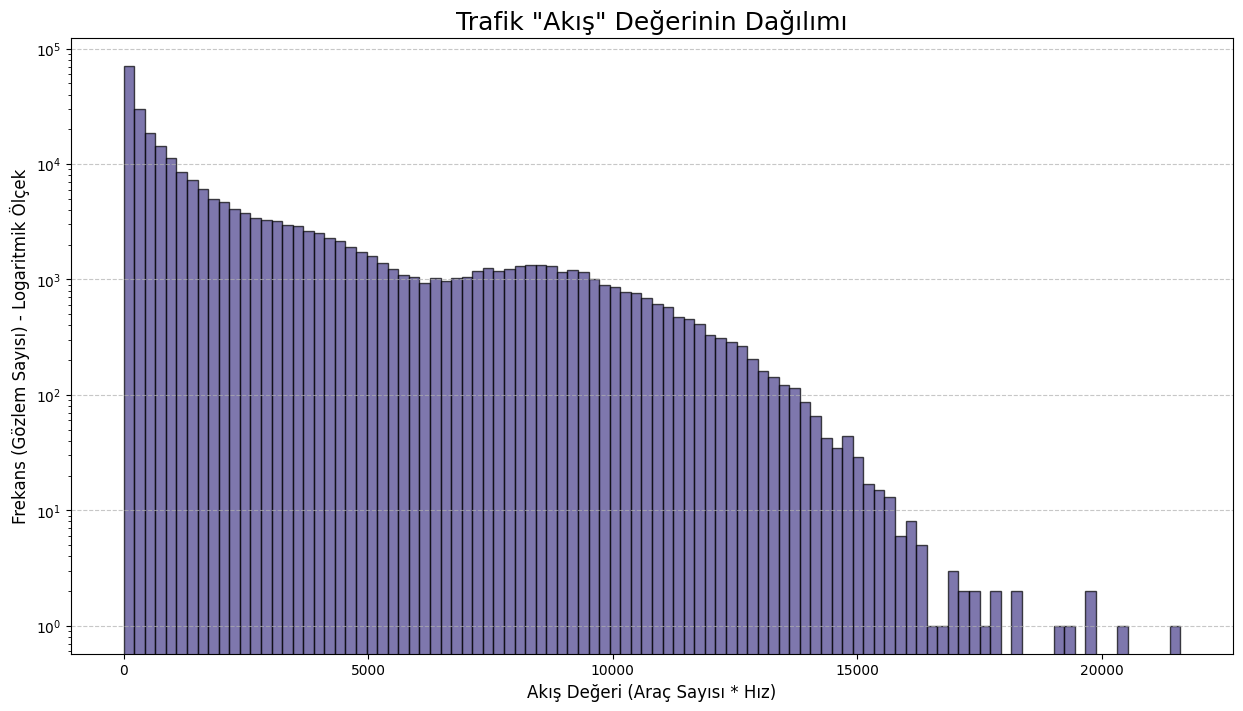

In [22]:
import matplotlib.pyplot as plt 

# yapılan iş formülünden
df['akis'] = df['total'] * df['speed']
# .describe() metodu, sütunun temel istatistiklerini (sayım, ortalama, min, max vb.) verir.
print(df['akis'].describe())


plt.figure(figsize=(15, 8))
# log=True parametresi, çok geniş bir aralığa yayılan verilerde küçük değerlerin de görünür olmasını sağlar.
plt.hist(df['akis'], bins=100, color='darkslateblue', edgecolor='black', alpha=0.7, log=True)
plt.title('Trafik "Akış" Değerinin Dağılımı', fontsize=18)
plt.xlabel('Akış Değeri (Araç Sayısı * Hız)', fontsize=12)
plt.ylabel('Frekans (Gözlem Sayısı) - Logaritmik Ölçek', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

grafik yolun çalışma performansı gibi düşünülebilir. model oluşturmada özellik olarak kullanılacağından yapıldı

OLAYLAR (yoğunluk oluşabilecek özel günller)

In [23]:
# Analiz periyodumuzdaki (Temmuz-Ekim 2022) resmi tatilleri bir listede tutalım.
# Arefe günlerini de eklemek, trafiğin bir gün önceden değiştiğini modele öğretebilir.
bayram_gunleri = [
    '2022-07-08', # Kurban Bayramı Arefesi
    '2022-07-09', '2022-07-10', '2022-07-11', '2022-07-12', # Kurban Bayramı
    '2022-08-30', # Zafer Bayramı
    '2022-10-28', # Cumhuriyet Bayramı Arefesi
    '2022-10-29'  # Cumhuriyet Bayramı
]
bayram_gunleri = pd.to_datetime(bayram_gunleri).date
okul_acilma_tarihi = pd.to_datetime('2022-09-12').date()


# Her bir kaydın tarihini alalım
gunler = df['start_time'].dt.date
df['bayram'] = gunler.isin(bayram_gunleri).astype(int)
df['okul'] = (gunler >= okul_acilma_tarihi).astype(int)


print("\nBayram günlerinden örnekler:")
print(df[df['bayram'] == 1][['start_time', 'bayram', 'okul']].head())
print("\nOkul döneminden örnekler:")
print(df[df['okul'] == 1][['start_time', 'bayram', 'okul']].head())



Bayram günlerinden örnekler:
               start_time  bayram  okul
17189 2022-07-08 00:00:00       1     0
17190 2022-07-08 00:00:00       1     0
17197 2022-07-08 00:05:00       1     0
17204 2022-07-08 00:10:00       1     0
17205 2022-07-08 00:10:00       1     0

Okul döneminden örnekler:
                start_time  bayram  okul
178423 2022-09-12 04:45:00       0     1
178425 2022-09-12 04:50:00       0     1
178431 2022-09-12 04:55:00       0     1
178432 2022-09-12 04:55:00       0     1
178437 2022-09-12 05:00:00       0     1


MODEL LIGHTGBM

VERİ SETİNİN TARİHSEL OLARAK AYRILMASI

In [24]:
df_final = pd.get_dummies(df_modelleme, columns=['serit_tipi', 'arac_tipi']) #serit ve araç tiplerini one-hot encoding ile sayısallaştırma

df_final = df_final.set_index('start_time')
# İpuçları (X) ve Hedefi (y) Belirleme
y = df_final['speed']
# hedef : 'speed' ve analizde kullanılmayacak diğer orijinal/gereksiz sütunlar dışındaki her şey.
X = df_final.drop(columns=[
    'speed', 'occupancy_time', 'total', 'end_time', 'id', 'intersection_id', 'camera_id',
    'direction', 'detector_id', 'class_id'
])

# Test setimiz, Ekim ayının verileri olacak. -- Eğitim setimiz ise Ekim'den önceki her şey (Temmuz, Ağustos, Eylül).
split_date = '2022-10-01'

# 'start_time' sütununu sildiğimiz için, indeksi kullanarak ayırma yapmalıyız. -- bunun için indeksi datetime formatına çevirelim.
X.index = pd.to_datetime(X.index)
y.index = pd.to_datetime(y.index)


# Eğitim setini oluştur (belirtilen tarihten önceki tüm veriler)
X_train = X[X.index < split_date]
y_train = y[y.index < split_date]

# Test setini oluştur (belirtilen tarihteki ve sonraki tüm veriler)
X_test = X[X.index >= split_date]
y_test = y[y.index >= split_date]


# sonuçlar
print(f"Eğitim Seti (İpuçları): {X_train.shape}")
print(f"Eğitim Seti (Hedef):    {y_train.shape}")
print(f"Test Seti (İpuçları):   {X_test.shape}")
print(f"Test Seti (Hedef):      {y_test.shape}")

Eğitim Seti (İpuçları): (218118, 24)
Eğitim Seti (Hedef):    (218118,)
Test Seti (İpuçları):   (30519, 24)
Test Seti (Hedef):      (30519,)


veri setinin verilerimizin bittiği tarihler civarında ayırma işlemi yapmamızın sebebi kronolojik tahmin yaptırdığımızdandır. Normal split metodu ile oransal olarak ayırım yapmamız modele direkt cevapları vermemiz anlamına gelir ve tutarlı sonuçlar elde edemeyiz. Bundan dolayı kronolojik tahminlerde manuel ayırma yapılmalıdır.

MODEL EĞİTİM ve RİSK METRİKLERİ

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2086
[LightGBM] [Info] Number of data points in the train set: 218118, number of used features: 24
[LightGBM] [Info] Start training from score 72.345675
Ortalama Mutlak Hata (MAE): 8.76 km/s
R-kare (R²) Skoru: 0.804
Anlamı: Trafik hızındaki değişkenliğin yaklaşık %80.4'ini bu modelle açıklayabiliyoruz.


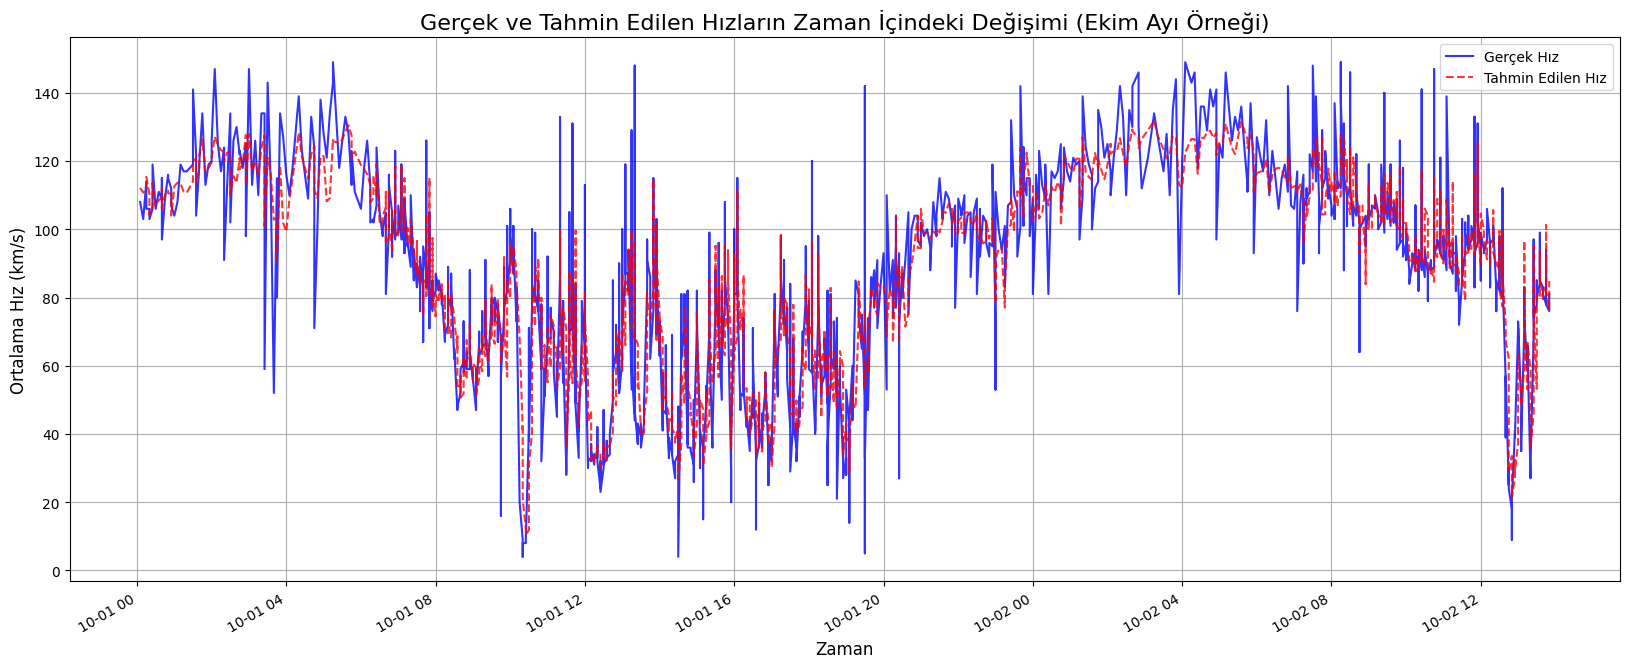

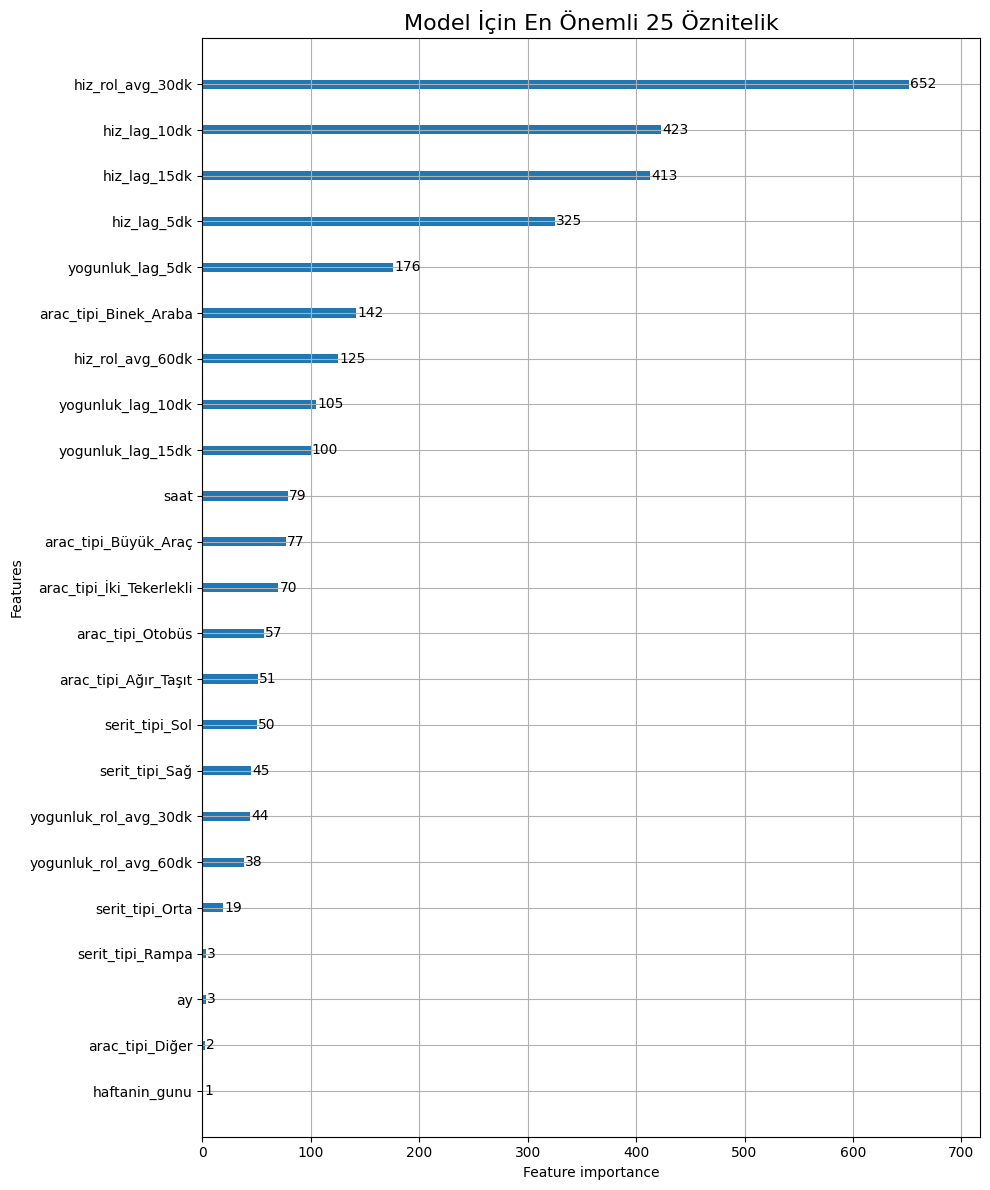

In [25]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score


# modelin eğitimi
lgbm_model = lgb.LGBMRegressor(random_state=42)
lgbm_model.fit(X_train, y_train)


# hiç görmediği X_test verisi için hız tahminleri 
y_pred = lgbm_model.predict(X_test)


# Ortalama Mutlak Hata (Mean Absolute Error - MAE)
# Tahminlerimizin gerçek değerlerden ortalama olarak ne kadar saptığını gösterir. (Düşük olması iyidir)
mae = mean_absolute_error(y_test, y_pred)
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f} km/s")


# R-kare (R²) Skoru
# Hızdaki değişkenliğin yüzde kaçını modelimizin açıklayabildiğini gösterir. (1'e yakın olması iyidir)
r2 = r2_score(y_test, y_pred)
print(f"R-kare (R²) Skoru: {r2:.3f}")
print(f"Anlamı: Trafik hızındaki değişkenliğin yaklaşık %{r2*100:.1f}'ini bu modelle açıklayabiliyoruz.")


# Zaman Serisi Üzerinde Karşılaştırma Grafiği
# Test setinden sadece belirli bir zaman aralığını (örneğin ilk 1000 kayıt) alarak daha okunaklı bir grafik çizelim
results_df = pd.DataFrame({'Gerçek Hız': y_test, 'Tahmin Edilen Hız': y_pred})
results_df.head(1000).plot(figsize=(20, 8), style=['b-', 'r--'], alpha=0.8)
plt.title('Gerçek ve Tahmin Edilen Hızların Zaman İçindeki Değişimi (Ekim Ayı Örneği)', fontsize=16)
plt.xlabel('Zaman', fontsize=12)
plt.ylabel('Ortalama Hız (km/s)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


# Öznitelik Önem Grafiği
# Modelin tahmin yaparken en çok hangi ipuçlarını kullandığını görelim
lgb.plot_importance(lgbm_model, figsize=(10, 12), max_num_features=25)
plt.title('Model İçin En Önemli 25 Öznitelik', fontsize=16)
plt.tight_layout()
plt.show()

model oldukça başarılı ancak parametrelerini daha da iyileştirebilirmiyiz diye bakalım

MODEL PARAMETRELERİNİ İYİLEŞTİRME (GRİD SEARCH İLE)

In [26]:
from sklearn.model_selection import GridSearchCV

# LightGBM için denemek istediğimiz hiperparametreleri ve olası değerlerini bir sözlükte belirtiyoruz.
param_grid = {
    'n_estimators': [400, 700, 1000],          # Ağaç sayısı
    'learning_rate': [0.05, 0.1],             # Öğrenme oranı
    'num_leaves': [31, 40, 50],               # Her ağaçtaki yaprak sayısı
    # Daha fazla parametre eklenebilir, ancak bu süreyi uzatır.
    # 'max_depth': [10, 15],
    # 'reg_alpha': [0.1, 0.5],
    # 'reg_lambda': [0.1, 0.5]
}

# grid model kurulumu ve temel modelimizi tanımlıyoruz
estimator = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# GridSearchCV'yi kuruyoruz
# scoring='neg_mean_absolute_error': Amacımız MAE'yi minimize etmek olduğu için 'negatif MAE'yi maksimize etmeye çalışırız.
# cv=3: 3-katlı çapraz doğrulama kullanır. Bu, sonuçların daha güvenilir olmasını sağlar.
# verbose=2: Arama sırasında ilerleme durumunu ekrana yazdırır.
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1 # Bilgisayarın tüm işlemci çekirdeklerini kullanır
)


print(f"Toplam {len(param_grid['n_estimators']) * len(param_grid['learning_rate']) * len(param_grid['num_leaves'])} farklı model kombinasyonu denenecek...")

# Arama işlemini eğitim verilerimizle başlatalım
grid_search.fit(X_train, y_train)


print("\n--- OPTİMİZASYON SONUÇLARI ---")
# En iyi performansı veren parametre kombinasyonunu yazdır
print("Bulunan en iyi parametreler:")
print(grid_search.best_params_)
# En iyi modelin çapraz doğrulama skorunu yazdır
# Skor negatif olduğu için -1 ile çarparak gerçek MAE değerini buluruz.
best_mae = -grid_search.best_score_
print(f"\nEn iyi modelin ortalama çapraz doğrulama MAE değeri: {best_mae:.3f} km/s")

Toplam 18 farklı model kombinasyonu denenecek...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Number of data points in the train set: 145412, number of used features: 23
[LightGBM] [Info] Start training from score 66.771174
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Number of data points in the train set: 1454

yeni modelimiz ilk yaptığımız modelden biraz daha kötü sonuç gösteridi. bunun ilk model tek sınav yapılması ve son modele cv_3 parametresi ile 3 sınav yaptırarak bu sınavların ortalaması olmasıdır. yani iki modelin sınavları farklı olduğundan tutarlu bir sonuç çıkaramayız

İKİ MODEL AYNI SINAV

In [ ]:
# Bir önceki hücrede 'grid_search' ile bulduğumuz en iyi parametreleri alıyoruz.
# Eğer o hücreyi tekrar çalıştırmadıysanız, en iyi parametreleri manuel olarak da girebilirsiniz.
# best_params = {'learning_rate': 0.05, 'n_estimators': 1000, 'num_leaves': 50} # Örnek
best_params = grid_search.best_params_

# Yeni LightGBM modelini bu en iyi parametrelerle başlatalım
lgbm_optimized = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1)
# Yeni, "uzman" modelimizi aynı eğitim verisiyle eğitelim
lgbm_optimized.fit(X_train, y_train)
print("Optimize edilmiş model başarıyla eğitildi.")


# Optimize edilmiş model ile tahmin yapalım
y_pred_optimized = lgbm_optimized.predict(X_test)

# Yeni modelin performans metriklerini hesaplayalım
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)


# Bir önceki standart modelin sonuçları
mae_standart = 7.74
r2_standart = 0.839


print("\n FİNAL RAPORU")
print(f"{'Metrik':<25} | {'Standart Model':<20} | {'Optimize Edilmiş Model':<25}")
print(f"{'Ortalama Hata (MAE)':<25} | {mae_standart:.2f} km/s{'':<12} | {mae_optimized:.2f} km/s")
print(f"{'Başarı Oranı (R² Skoru)':<25} | {r2_standart:.3f}{'':<17} | {r2_optimized:.3f}")


# sonuç
if mae_optimized < mae_standart: # parametreler gerçekten iyileşmişse
    iyilesme = mae_standart - mae_optimized
    print(f"\nSONUÇ: Başarılı! Optimizasyon, modelin hata payını {iyilesme:.2f} km/s daha düşürerek daha isabetli hale getirdi.")
else: # parametreler iyileşmediyse
    print(f"\n SONUÇ: Optimizasyon, bu spesifik test setinde standart modelden daha iyi bir sonuç vermedi.")
    print("Bu, standart ayarların zaten oldukça iyi olduğu veya arama uzayının daha da genişletilmesi gerektiği anlamına gelebilir.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2517
[LightGBM] [Info] Number of data points in the train set: 218118, number of used features: 26
[LightGBM] [Info] Start training from score 72.345675
Optimize edilmiş model başarıyla eğitildi.

 FİNAL RAPORU
Metrik                    | Standart Model       | Optimize Edilmiş Model   
Ortalama Hata (MAE)       | 7.74 km/s             | 7.46 km/s
Başarı Oranı (R² Skoru)   | 0.839                  | 0.849

SONUÇ: Başarılı! Optimizasyon, modelin hata payını 0.28 km/s daha düşürerek daha isabetli hale getirdi.
